# Phase 6: policies and shocks on common random numbers

Every policy is a set of hooks on the same simulation; every shock is a dated intervention on the same draws. A
difference between two outcome distributions is therefore the intervention, not the dice. All four shocks are run and
none is privileged; paths are filtered only by feasibility.

Every magnitude inside the policies is a placeholder (P-06 to P-09). The shocks are one-standard-deviation-scale
impulses on the block factors or forced transitions into the stress state; their sizes are stated in the cell.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown
import bond_sim.notebook as nb
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 80)
plt.rcParams["figure.dpi"] = 110

# ── parameters: change and rerun ─────────────────────────────────────────────
AS_OF = pd.Timestamp("2026-09-15")     # every loader filters on this date (point-in-time contract)
K = 1000                                 # Monte Carlo paths (raise for the paper)
FORCE_REFRESH = False                  # True re-downloads every series and rebuilds cached steps
os.environ["BOND_SIM_CACHE"] = "0" if FORCE_REFRESH else "1"
import bond_sim.config as bcfg
CFG_HASH = bcfg.load().content_hash()   # every cached step is keyed by the configuration that produced it
ctx = nb.cached(f"ctx_{AS_OF.date()}_{CFG_HASH}", lambda: nb.load_context(AS_OF), refresh=FORCE_REFRESH)
print(ctx.grid, "| config hash", CFG_HASH, "| series:", ctx.w.shape[1])

MonthlyGrid(1980-01-01 .. 2056-09-01, M=921) | config hash d9222bd624fd | series: 48


In [2]:
from bond_sim.sim import ForcedTransition, FactorImpulse, StateBlock
book, auctions, agg, short = nb.cached(f"book_{AS_OF.date()}_{CFG_HASH}", lambda: nb.build_book(ctx), refresh=FORCE_REFRESH)
bf, chain = nb.cached(f"factors_chain_{AS_OF.date()}_{CFG_HASH}", lambda: nb.fit_factors_and_chain(ctx), refresh=FORCE_REFRESH)
var = nb.fit_var(ctx); init = nb.initial_state(ctx, book, auctions); H_, feas, h = nb.history_sustainability(ctx, agg)
SHOCKS = {
    "none": None,
    "recession_now": [ForcedTransition(state=0, at=0, duration=4, label="forced into the stress state for 4 quarters")],
    "rate_spike": [FactorImpulse("rates", +2.0, at=0, decay=0.8), FactorImpulse("financial", -1.5, at=0, decay=0.7)],
    "foreign_withdrawal": [FactorImpulse("fiscal", -1.5, at=0, decay=0.85), FactorImpulse("financial", -1.0, at=0, decay=0.8)],
    "consumer_retrenchment": [FactorImpulse("consumer", -2.0, at=0, decay=0.8)],
}
POLICIES = list(ctx.cfg.policy.menu)
states_factory = lambda shocks: nb.make_blocks(ctx, var, bf, chain, shocks)["states"]
runs = nb.cached(f"runs_policies_shocks_{AS_OF.date()}_{CFG_HASH}_K1000", lambda: nb.run_scenarios(ctx, init, feas, states_factory, POLICIES, K, SHOCKS), refresh=FORCE_REFRESH)
tab = nb.summary_table(runs)
display(tab.round(3))

,shock,policy,block,admissible_share,P(trigger),P(trigger_threshold),median_years_to_trigger,median_end_debt_gdp,median_end_r10,median_end_u,median_end_g_nom,median_end_pb,median_end_interest_12m_gdp,median_end_r_eff,median_end_infl
0,none,status_quo,2-state latent chain on 7 block factors (hazar...,0.996,0.583,0.503,14.167,121.226,4.216,5.115,4.951,-1.996,4.160,3.568,2.794
1,none,no_layoff_mandate,2-state latent chain on 7 block factors (hazar...,0.996,0.610,0.519,14.167,123.403,4.252,5.034,4.895,-1.998,4.223,3.580,2.791
2,none,austerity,2-state latent chain on 7 block factors (hazar...,0.989,0.273,0.000,7.750,19.897,3.718,5.111,5.182,2.000,0.927,4.774,2.817
3,none,monetization,2-state latent chain on 7 block factors (hazar...,0.996,0.102,0.059,16.792,77.601,3.747,5.115,6.972,-1.991,2.440,3.236,2.810
4,none,growth_led,2-state latent chain on 7 block factors (hazar...,0.996,0.416,0.349,15.125,106.569,3.968,5.115,5.454,-1.986,3.547,3.425,2.807
5,recession_now,status_quo,2-state latent chain on 7 block factors (hazar...,0.996,0.641,0.495,10.167,123.101,4.240,5.115,4.940,-1.995,4.188,3.578,2.792
6,recession_now,no_layoff_mandate,2-state latent chain on 7 block factors (hazar...,0.996,0.661,0.516,9.750,124.769,4.274,5.025,4.897,-1.997,4.295,3.600,2.792
7,recession_now,austerity,2-state latent chain on 7 block factors (hazar...,0.987,0.407,0.002,2.708,19.141,3.714,5.115,5.182,2.000,0.922,4.933,2.817
8,recession_now,monetization,2-state latent chain on 7 block factors (hazar...,0.996,0.144,0.063,10.417,78.549,3.748,5.115,6.966,-1.991,2.434,3.224,2.811
9,recession_now,growth_led,2-state latent chain on 7 block factors (hazar...,0.996,0.480,0.353,9.958,108.320,3.995,5.115,5.451,-1.993,3.563,3.426,2.806


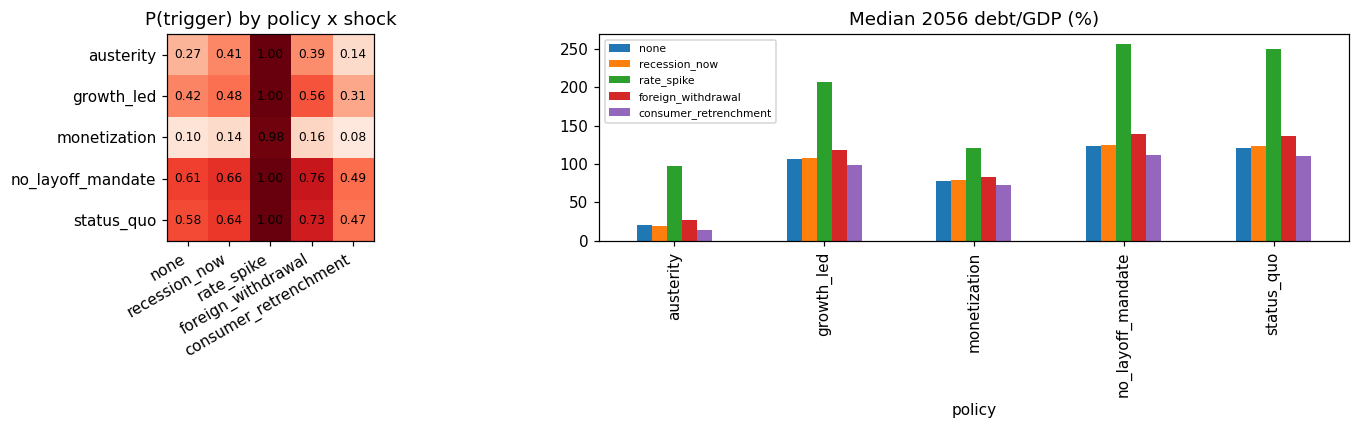

In [3]:
piv = tab.pivot(index="policy", columns="shock", values="P(trigger)")[list(SHOCKS)]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
im = ax[0].imshow(piv.to_numpy(), cmap="Reds", vmin=0, vmax=1); ax[0].set_xticks(range(len(piv.columns))); ax[0].set_xticklabels(piv.columns, rotation=30, ha="right")
ax[0].set_yticks(range(len(piv.index))); ax[0].set_yticklabels(piv.index); ax[0].set_title("P(trigger) by policy x shock")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax[0].text(j, i, f"{piv.iat[i, j]:.2f}", ha="center", va="center", fontsize=8)
piv2 = tab.pivot(index="policy", columns="shock", values="median_end_debt_gdp")[list(SHOCKS)]
piv2.plot.bar(ax=ax[1]); ax[1].set_title("Median 2056 debt/GDP (%)"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 6.1 Fan charts for the recession shock across policies

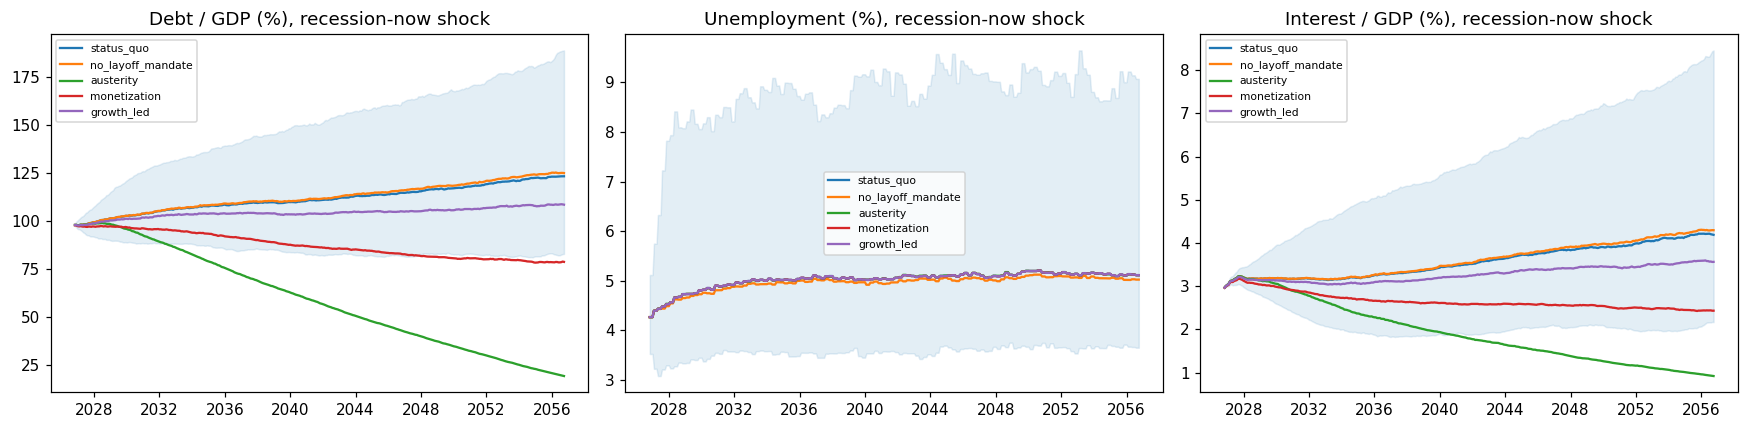

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, v, title in zip(axes, ("debt_gdp", "u", "interest_12m_gdp"), ("Debt / GDP (%)", "Unemployment (%)", "Interest / GDP (%)")):
    for p in POLICIES:
        nb.fan(ax, runs[("recession_now", p)], v, p, band=(p == "status_quo"))
    ax.set_title(f"{title}, recession-now shock"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 6.2 Act now or act later

The same policy started today, in five years, and in ten years, on the same draws (no shock). The gap between the
curves is the cost of waiting under the placeholder magnitudes.

P(trigger)               median_end_debt_gdp                   median_end_u              
start_year       0.0    5.0    10.0                0.0      5.0      10.0         0.0    5.0    10.0
policy                                                                                              
austerity       0.273  0.396  0.478              19.897   33.444   49.185        5.111  5.115  5.114
growth_led      0.416  0.447  0.476             106.569  108.454  110.549        5.115  5.115  5.115

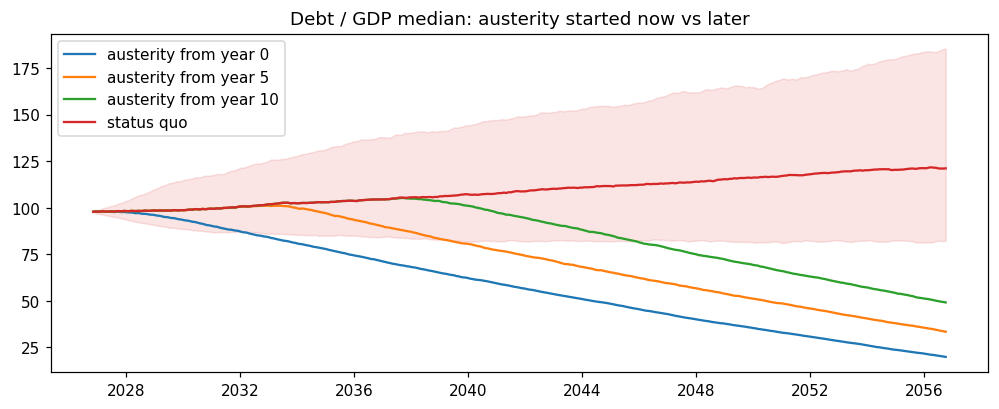

In [5]:
delayed = {}
for start_q in (0, 20, 40):
    delayed[start_q] = nb.run_scenarios(ctx, init, feas, states_factory, ["austerity", "growth_led"], K, {"none": None}, policy_start_quarter=start_q)
rows = []
for start_q, rr in delayed.items():
    for (s, p), r in rr.items():
        rows.append({"policy": p, "start_year": start_q / 4, "P(trigger)": r.trigger_probability(), "median_end_debt_gdp": float(np.median(r.paths["debt_gdp"][r.admissible, -1])),
                     "median_end_u": float(np.median(r.paths["u"][r.admissible, -1]))})
display(pd.DataFrame(rows).pivot(index="policy", columns="start_year").round(3))
fig, ax = plt.subplots(figsize=(11, 4))
for start_q, rr in delayed.items():
    nb.fan(ax, rr[("none", "austerity")], "debt_gdp", f"austerity from year {start_q // 4}", band=False)
nb.fan(ax, runs[("none", "status_quo")], "debt_gdp", "status quo", band=True)
ax.set_title("Debt / GDP median: austerity started now vs later"); ax.legend(); plt.show()

## 6.3 The VAR block as a cross-check (policies, no shocks)

In [6]:
var_factory = lambda shocks: nb.make_blocks(ctx, var, bf, chain, shocks)["VAR"]
runs_var = nb.cached(f"runs_policies_var_{AS_OF.date()}_{CFG_HASH}_K1000", lambda: nb.run_scenarios(ctx, init, feas, var_factory, POLICIES, K, {"none": None}), refresh=FORCE_REFRESH)
cmp = pd.concat([nb.summary_table(runs_var).assign(block="VAR"), nb.summary_table({k: v for k, v in runs.items() if k[0] == "none"}).assign(block="states")])
display(cmp.set_index(["block", "policy"])[["admissible_share", "P(trigger)", "median_years_to_trigger", "median_end_debt_gdp", "median_end_r10", "median_end_u"]].round(3))

admissible_share  P(trigger)  median_years_to_trigger  median_end_debt_gdp  median_end_r10  median_end_u
block  policy                                                                                                                     
VAR    status_quo                    1.000       0.603                   16.917              148.271           5.050         5.015
       no_layoff_mandate             0.993       0.985                    7.917              298.038           6.863         4.741
       austerity                     1.000       0.841                    6.417               32.510           3.751         5.672
       monetization                  0.826       0.000                      NaN               22.655           5.895         2.879
       growth_led                    1.000       0.214                   17.750              102.997           4.757         4.342
states status_quo                    0.996       0.583                   14.167              121.226           4.216         5.115
       no_layoff_mandate             0.996       0.610                   14.167              123.403           4.252         5.034
       austerity                     0.989       0.273                    7.750               19.897           3.718         5.111
       monetization                  0.996       0.102                   16.792               77.601           3.747         5.115
       growth_led                    0.996       0.416                   15.125              106.569           3.968         5.115